In [1]:
from anchoring_detection.preprocess import Preprocess
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import os

In [12]:
path = '/home/arturo/Documentos/Mooring_anomaly_detector/data/tdyn_seafem/simulations'

## Time domain Dataframe

In [13]:
# Escribimos la información del .res en un .txt
txt_path= os.path.join(path,'oc4__Hs2__Tp3__dir5__1.txt')
# Almaceno los resultados del número de simulaciones empleado
df = pd.read_csv(txt_path, sep='\t', header=4).iloc[:,:7]

In [14]:
df

,time[s],Surge,Sway,Heave,Roll,Pitch,Yaw
0,180.0,-7.18245,3.70707,-0.526732,-0.003976,-0.087494,0.000255
1,180.1,-7.20735,3.70920,-0.561467,-0.003958,-0.087498,0.000267
2,180.2,-7.22993,3.71156,-0.597012,-0.003942,-0.087507,0.000287
3,180.3,-7.25012,3.71415,-0.633307,-0.003926,-0.087520,0.000313
4,180.4,-7.26788,3.71697,-0.670293,-0.003911,-0.087537,0.000347
...,...,...,...,...,...,...,...
10196,1199.6,-4.65400,5.12239,-0.242937,-0.004537,-0.091401,0.010846
10197,1199.7,-4.70476,5.12059,-0.256773,-0.004534,-0.091286,0.010933
10198,1199.8,-4.75550,5.11879,-0.272012,-0.004533,-0.091176,0.011033
10199,1199.9,-4.80606,5.11698,-0.288636,-0.004532,-0.091071,0.011144


MODIFICACIÓN DEL MODULO PREPROCESS

In [21]:
dataframes_surge = {}
dataframes_sway = {}
Hs =  ['Hs1','Hs2','Hs3','Hs4']
Tp = ['Tp2','Tp3','Tp4','Tp5']
direction = ['dir1','dir2','dir3','dir4','dir5']
cases = ['1','2']
movements = ['Surge', 'Sway']
aumentation = 'yes'

for h in Hs:
    for t in Tp:
        for dir in direction:
            for case in cases:

                simulation = f'oc4__{h}__{t}__{dir}__{case}'
                txt_path = os.path.join(path,f'{simulation}.txt')

                if os.path.exists(txt_path):
                    # Store results in a dictionary of dataframes
                    df = pd.read_csv(txt_path, sep='\t', header=4).iloc[:,:7]
                    for mov in movements:
                        if mov == 'Surge':
                            dataframes_surge[simulation] = df[['time[s]','Surge']]
                        else:
                            dataframes_sway[simulation] = df[['time[s]','Sway']]

In [19]:
for direction, dataframes in {"Surge": dataframes_surge, "Sway": dataframes_sway}.items():
    for key, df in dataframes.items():
        for col in df.columns[1:]:
            df[col] = df[col] - df[col].mean()

In [23]:
for mov in movements:
    if mov == 'Surge':
        dataframes = dataframes_surge
    else:
        dataframes = dataframes_sway

    # Group the data in one unique dataframe
    df= pd.concat(dataframes.values(), axis=1)
    df_time = df.iloc[:,0]
    df = df.drop(df.filter(like='time[s]').columns, axis=1)
    df.insert(0,'Time',df_time)

    # the number of txt files is the same of dataframe amplitude columns. We are going to regroup with only one "freq_colum" because it is the same
    lista_archivos = os.listdir(path)

    if len(lista_archivos) == (len(df.columns) - 1):
        df.columns = ['Time'] + lista_archivos

    if mov == 'Surge':
        df_surge = df
    else:
        df_sway = df

/tmp/ipykernel_8528/1938273773.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(0,'Time',df_time)
/tmp/ipykernel_8528/1938273773.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(0,'Time',df_time)


In [24]:
df_surge

,Time,oc4__Hs1__Tp2__dir3__1.txt,oc4__Hs1__Tp4__dir2__2.txt,oc4__Hs1__Tp5__dir1__1.txt,oc4__Hs1__Tp4__dir4__2.txt,oc4__Hs1__Tp2__dir3__2.txt,oc4__Hs2__Tp5__dir4__2.txt,oc4__Hs3__Tp4__dir2__1.txt,oc4__Hs1__Tp5__dir5__2.txt,oc4__Hs3__Tp5__dir4__1.txt,...,oc4__Hs2__Tp3__dir4__1.txt,oc4__Hs1__Tp2__dir4__2.txt,oc4__Hs2__Tp4__dir2__2.txt,oc4__Hs1__Tp2__dir2__2.txt,oc4__Hs2__Tp4__dir1__1.txt,oc4__Hs3__Tp5__dir1__1.txt,oc4__Hs1__Tp3__dir3__2.txt,oc4__Hs1__Tp2__dir5__2.txt,oc4__Hs2__Tp3__dir3__2.txt,oc4__Hs3__Tp5__dir5__1.txt
0,180.0,-5.67869,11.2440,-5.64312,11.2795,-5.66287,11.2600,-5.67179,11.2516,-5.74850,...,-4.89227,12.0386,-5.17427,11.7328,-5.58502,11.3243,-6.03707,10.8966,-6.62051,10.36290
1,180.1,-5.67247,11.2565,-5.63881,11.2901,-5.66013,11.2691,-5.67172,11.2579,-5.75294,...,-4.78142,12.1555,-5.11321,11.8000,-5.58002,11.3356,-6.08838,10.8517,-6.73449,10.25550
2,180.2,-5.66642,11.2689,-5.63465,11.3006,-5.65739,11.2781,-5.67161,11.2644,-5.75695,...,-4.66941,12.2736,-5.05197,11.8674,-5.57537,11.3465,-6.14056,10.8059,-6.84943,10.14720
3,180.3,-5.66057,11.2810,-5.63068,11.3109,-5.65469,11.2871,-5.67145,11.2708,-5.76050,...,-4.55637,12.3927,-4.99060,11.9349,-5.57108,11.3571,-6.19354,10.7594,-6.96519,10.03810
4,180.4,-5.65496,11.2929,-5.62688,11.3209,-5.65201,11.2961,-5.67123,11.2773,-5.76355,...,-4.44243,12.5127,-4.92918,12.0025,-5.56713,11.3673,-6.24723,10.7121,-7.08162,9.92833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10196,1199.6,-4.24638,19.6387,-4.18836,19.6966,-4.11576,19.7691,-4.04045,19.8444,-3.93729,...,1.67808,25.5251,-1.12073,22.7190,-4.02865,19.8224,-7.03885,16.8271,-10.12470,13.75810
10197,1199.7,-4.24186,19.6433,-4.19011,19.6949,-4.11961,19.7653,-4.04657,19.8383,-3.93867,...,1.74588,25.5930,-1.08795,22.7518,-4.02769,19.8233,-7.07088,16.7950,-10.18670,13.69620
10198,1199.8,-4.23708,19.6480,-4.19173,19.6933,-4.12340,19.7615,-4.05272,19.8322,-3.94034,...,1.80871,25.6560,-1.05788,22.7818,-4.02707,19.8238,-7.10070,16.7652,-10.24380,13.63910
10199,1199.9,-4.23206,19.6531,-4.19318,19.6918,-4.12713,19.7578,-4.05888,19.8260,-3.94233,...,1.86651,25.7139,-1.03054,22.8092,-4.02678,19.8240,-7.12831,16.7375,-10.29610,13.58690


## Transformada de fourier

centrar la plataforma

In [5]:
df.columns[1:]

Index(['Surge', 'Sway', 'Heave', 'Roll', 'Pitch', 'Yaw'], dtype='object')

In [6]:
for col in df.columns[1:]:
    df[col] = df[col]-df[col].mean()
df

,time[s],Surge,Sway,Heave,Roll,Pitch,Yaw
0,180.0,-2.993283,-1.363304,0.773506,0.000638,0.004896,-0.007338
1,180.1,-3.018183,-1.361174,0.738771,0.000656,0.004892,-0.007326
2,180.2,-3.040763,-1.358814,0.703226,0.000673,0.004884,-0.007307
3,180.3,-3.060953,-1.356224,0.666931,0.000688,0.004871,-0.007280
4,180.4,-3.078713,-1.353404,0.629945,0.000703,0.004854,-0.007246
...,...,...,...,...,...,...,...
10196,1199.6,-0.464833,0.052016,1.057301,0.000078,0.000990,0.003253
10197,1199.7,-0.515593,0.050216,1.043465,0.000080,0.001104,0.003340
10198,1199.8,-0.566333,0.048416,1.028226,0.000082,0.001214,0.003440
10199,1199.9,-0.616893,0.046606,1.011602,0.000082,0.001319,0.003551


Realizamos la transformada de fourier. Es necesario transformar las columnas a vectores numpy. Podríamos hacer las FFT desde SeaFEM pero hacer eso manualmente es tedioso.

In [7]:
mov = df['Surge'].to_numpy()
time = df['time[s]'].to_numpy()

In [8]:
mov

array([-2.99328293, -3.01818293, -3.04076293, ..., -0.56633293,
       -0.61689293, -0.66710293])

Text(0, 0.5, 'Amplitud')

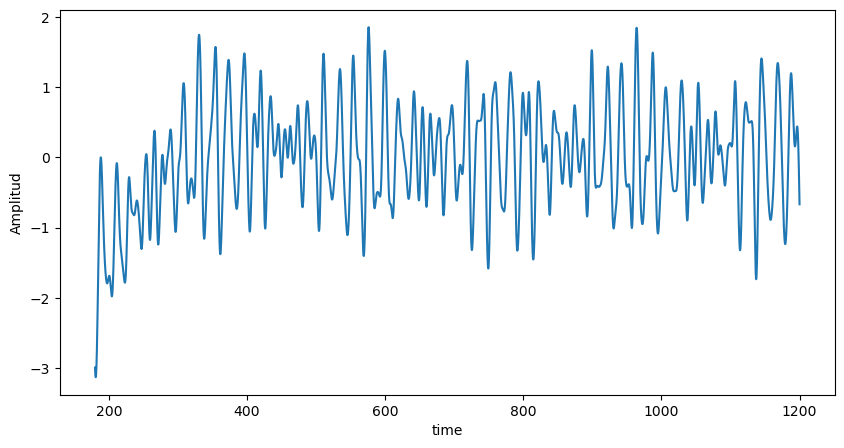

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(time, mov)
#plt.title('dominio del tiempo Surge')
#plt.xlim(450,1100)
plt.xlabel('time')
plt.ylabel('Amplitud')

In [11]:
fft_mov = fft(mov)

N=len(fft_mov)
fft_freq = fftfreq(N,0.1)[:N//2]

In [12]:
fft_freq

array([0.00000000e+00, 9.80296049e-04, 1.96059210e-03, ...,
       4.99656896e+00, 4.99754926e+00, 4.99852956e+00])

In [13]:
fft_mov

array([-7.55751017e-12  -0.j        , -9.25643216e+02+103.00672947j,
       -1.01845522e+03+411.65834378j, ..., -7.05825645e+02-777.93717628j,
       -1.01845522e+03-411.65834378j, -9.25643216e+02-103.00672947j])

In [14]:
amplitudes = 1/N* np.abs(fft_mov[0:N//2])

In [15]:
amplitudes

array([7.40859737e-16, 9.13005529e-02, 1.07686029e-01, ...,
       1.12186231e-04, 1.12128093e-04, 1.12154439e-04])

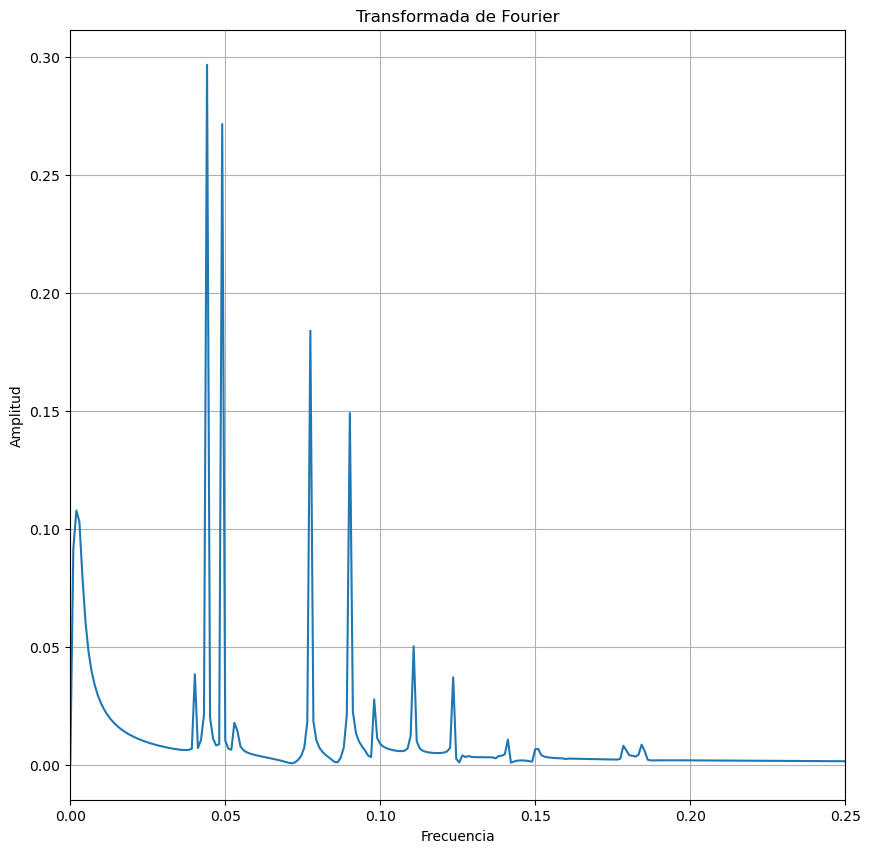

In [16]:
plt.figure(figsize=(10, 10))
plt.plot(fft_freq, amplitudes)
plt.title('Transformada de Fourier')
plt.xlim(0,0.25)
plt.xlabel('Frecuencia')
plt.ylabel('Amplitud')
plt.grid()

## Extracción de parámetros estadísticos

In [17]:
m = prob_moment.Probability_Moment(amplitudes,fft_freq)

m0 = m.momentn(0)
m2 = m.momentn(2)
m4 = m.momentn(4)

In [18]:
m0

0.003972946575057082

In [19]:
m2

0.22131829179184326

In [20]:
m4

117.17416575280339

In [163]:
# organicemos un df
Hs = 1.21
Tp  = 8.15
heading = 0.0
movements = list(df.columns[1:])

In [165]:
movements

['Surge', 'Sway', 'Heave', 'Roll', 'Pitch', 'Yaw']

In [167]:
columns = ['Hs', 'Tp', 'heading'] + movements
dataset = pd.DataFrame(columns=columns)

,Hs,Tp,heading,Surge,Sway,Heave,Roll,Pitch,Yaw


La intención es que el valor de cada movimiento almacene un array con los parámetros estadísticos, ya que así nuestro dataset sería mas ligero para entrenarlo

## Probando métodos de nuevo

In [2]:
anchoring = Preprocess()

In [3]:
anchoring.work_definitions(aumentation='nwrro')

Value error: nwrro. Only allowed 'yes' or 'no' 
